# Evaluation

Here I load the best fine-tuned models and evaluate them

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/ML_project/"

COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

## Setup

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, accuracy_score, confusion_matrix
)
from sklearn.model_selection import train_test_split
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data Loading

I replicate the exact same preprocessing and splits used during training to guarantee that val/test indices align with the saved model checkpoints.

In [ ]:
test_df = pd.read_csv(f"{path}/checkpoints/test_df.csv")
val_df = pd.read_csv(f"{path}/checkpoints/val_df.csv")

## Load Models & Run Inference

I load the best checkpoint for each model and run inference on the test split. TF-IDF predictions were saved directly during training.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification


class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length", max_length=max_length
        )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }


def run_inference(model, dataset, batch_size=64):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()
    logits_list, labels_list = [], []
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device),
            )
            logits_list.append(outputs.logits.cpu().numpy())
            labels_list.append(batch["labels"].numpy())
    return np.concatenate(logits_list), np.concatenate(labels_list)


tokenizer = RobertaTokenizerFast.from_pretrained(f"{path}/checkpoints/tokenizer")


In [ ]:
# best performing model a was trained with config_3
model_a = RobertaForSequenceClassification.from_pretrained(f"{path}/checkpoints/model_a/config_3")
model_a.resize_token_embeddings(len(tokenizer))
model_a.to(device)
test_ds_a = TextDataset(test_df["text"], test_df["label"], tokenizer)
val_ds_a = TextDataset(val_df["text"], val_df["label"], tokenizer)

In [ ]:
val_logits_a, val_labels_a = run_inference(model_a, val_ds_a)
test_logits_a, test_labels_a = run_inference(model_a, test_ds_a)

np.save(f"{path}/outputs/metrics/model_a_test_labels.npy", test_labels_a)
np.save(f"{path}/outputs/metrics/model_a_test_logits.npy", test_logits_a)
np.save(f"{path}/outputs/metrics/model_a_val_labels.npy", val_labels_a)
np.save(f"{path}/outputs/metrics/model_a_val_logits.npy", val_logits_a)

In [ ]:
def prepend_platform(df):
    return df.apply(lambda r: f"[PLATFORM: {r['source']}] {r['text']}", axis=1)

In [ ]:
model_b = RobertaForSequenceClassification.from_pretrained(f"{path}/checkpoints/model_b/config_3")
model_b.resize_token_embeddings(len(tokenizer))
model_b.to(device)

test_ds_b = TextDataset(prepend_platform(test_df), test_df["label"], tokenizer)
val_ds_b = TextDataset(prepend_platform(val_df), val_df["label"], tokenizer)
val_logits_b, val_labels_b = run_inference(model_b, val_ds_b)
test_logits_b, test_labels_b = run_inference(model_b, test_ds_b)

np.save(f"{path}/outputs/metrics/model_b_test_labels.npy", test_labels_b)
np.save(f"{path}/outputs/metrics/model_b_test_logits.npy", test_logits_b)
np.save(f"{path}/outputs/metrics/model_b_val_labels.npy", val_labels_b)
np.save(f"{path}/outputs/metrics/model_b_val_logits.npy", val_logits_b)

In [ ]:
# TF-IDF models: load pre-saved logits
test_logits_lr = np.load(f"{path}/checkpoints/tfidf_baseline/test_logits.npy")
test_labels_lr = np.load(f"{path}/checkpoints/tfidf_baseline/test_labels.npy")
test_logits_lrp = np.load(f"{path}/checkpoints/tfidf_platform/test_logits.npy")
test_labels_lrp = np.load(f"{path}/checkpoints/tfidf_platform/test_labels.npy")

val_logits_lr = np.load(f"{path}/checkpoints/tfidf_baseline/val_logits.npy")
val_labels_lr = np.load(f"{path}/checkpoints/tfidf_baseline/val_labels.npy")
val_logits_lrp = np.load(f"{path}/checkpoints/tfidf_platform/val_logits.npy")
val_labels_lrp = np.load(f"{path}/checkpoints/tfidf_platform/val_labels.npy")

In [ ]:
# load pre-saved model a and b labels and logits for validation set
val_logits_a = np.load(f"{path}/outputs/metrics/model_a_val_logits.npy")
val_labels_a = np.load(f"{path}/outputs/metrics/model_a_val_labels.npy")
val_logits_b = np.load(f"{path}/outputs/metrics/model_b_val_logits.npy")
val_labels_b = np.load(f"{path}/outputs/metrics/model_b_val_labels.npy")

# load pre-saved model a and b labels and logits for test set
test_logits_a = np.load(f"{path}/outputs/metrics/model_a_test_logits.npy")
test_labels_a = np.load(f"{path}/outputs/metrics/model_a_test_labels.npy")
test_logits_b = np.load(f"{path}/outputs/metrics/model_b_test_logits.npy")
test_labels_b = np.load(f"{path}/outputs/metrics/model_b_test_labels.npy")

# Evaluation metric explanation
ROC curve plots True Positive Rate vs False Positive Rate across every possible decision threshold.
It shows the full tradeoff between catching AI-generated posts (TPR) and falsely flagging human posts (FPR),
independent of any single threshold choice. AUC summarizes this into one number: 1.0 = perfect, 0.5 = random.


My models have a classifier head with 2 output neurons so for each input post, the model outputs two raw scores (logits), where a higher score means the model leans more toward that class. I use softmax to turn scores into probabilities and then I take only the second value.

Now for decision threshold: if the probability is above the threshold I say AI, otherwise human generated. The default would be 0.5, but I can move it depending on how strict I want it to be.

Finally, I choose the operating threshold on the validation set by finding the highest threshold where FPR stays at or below 5% (like the paper);  Then apply that fixed threshold to the test set to get our final predictions and compute F1 and accuracy.

- `threshold_at_5fpr`: picks the decision threshold that keeps FPR ≤ 5% on a given set.
- `compute_metrics`: runs evaluation
- `subset_metrics`: evaluates for a specific threshold

In [ ]:
def threshold_at_5fpr(labels, probs):
    """Return the highest threshold where FPR is still <= 5%."""
    fpr, _, thresholds = roc_curve(labels, probs)
    idx = np.searchsorted(fpr, 0.05, side="right") - 1
    idx = max(0, min(idx, len(thresholds) - 1))
    return float(thresholds[idx])


def compute_metrics(val_logits, val_labels, test_logits, test_labels):
    """Full evaluation: calibrate threshold on val, report metrics on test."""
    # converting logits to probabilities for the positive class
    val_probs = softmax(val_logits, axis=1)[:, 1]
    test_probs = softmax(test_logits, axis=1)[:, 1]
    threshold = threshold_at_5fpr(val_labels, val_probs)
    test_preds = (test_probs >= threshold).astype(int)
    return {
        "auc_roc": roc_auc_score(test_labels, test_probs),
        "f1_macro": f1_score(test_labels, test_preds, average="macro"),
        "accuracy": accuracy_score(test_labels, test_preds),
        "threshold": threshold,
        "test_probs": test_probs,
        "test_preds": test_preds,
        "test_labels": test_labels,
    }


def subset_metrics(probs, labels, threshold):
    """AUC-ROC and F1-macro for a subset using a fixed threshold."""
    preds = (probs >= threshold).astype(int)
    return {
        "auc_roc": roc_auc_score(labels, probs),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

## Overall Performance Summary

Here I compare all models on the test set.
The threshold is set once per model on the validation set (≤ 5% FPR) and then applied to the test set.

In [ ]:
model_specs = [
    ("Roberta", val_logits_a, val_labels_a, test_logits_a, test_labels_a),
    ("Roberta + Platform", val_logits_b, val_labels_b, test_logits_b, test_labels_b),
    ("LR", val_logits_lr, val_labels_lr, test_logits_lr, test_labels_lr),
    ("LR + Platform", val_logits_lrp, val_labels_lrp, test_logits_lrp, test_labels_lrp),
]

results = {}
for name, v_logits, v_labels, t_logits, t_labels in model_specs:
    results[name] = compute_metrics(v_logits, v_labels, t_logits, t_labels)

MODEL_NAMES = [name for name, *_ in model_specs]

In [ ]:
summary = pd.DataFrame(
    {
        name: {
            "AUC-ROC": round(r["auc_roc"], 4),
            "F1-Macro": round(r["f1_macro"], 4),
            "Accuracy": round(r["accuracy"], 4),
            "Threshold": round(r["threshold"], 4),
        }
        for name, r in results.items()
    }
).T

summary.to_csv(f"{path}/outputs/metrics/overall_summary.csv")
summary

,AUC-ROC,F1-Macro,Accuracy,Threshold
Roberta,0.9606,0.7363,0.8609,0.9749
Roberta + Platform,0.9577,0.7070,0.8354,0.9837
LR,0.9418,0.6261,0.7503,0.9404
LR + Platform,0.9449,0.6355,0.7604,0.9372


plotting the results

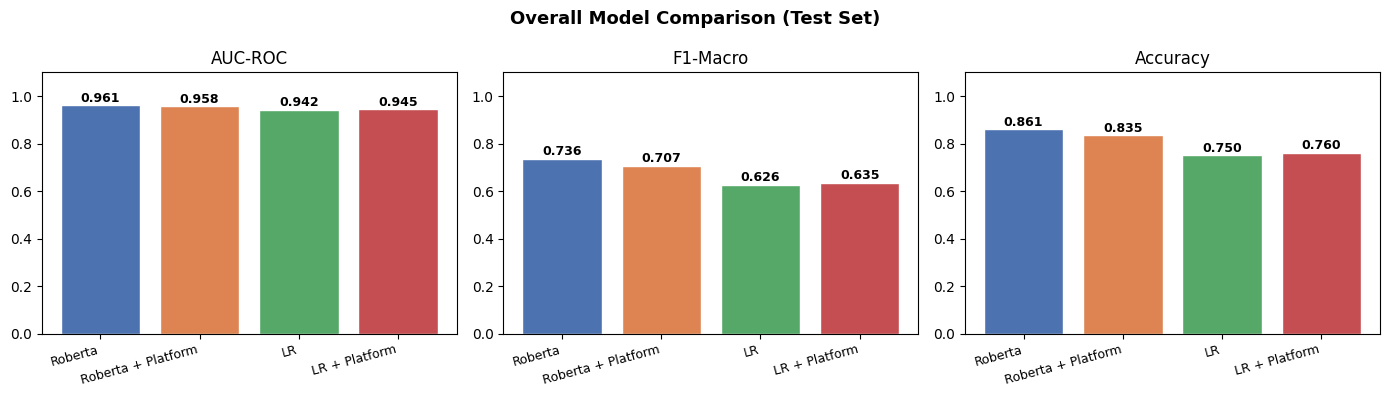

In [ ]:
metric_keys = [("AUC-ROC", "auc_roc"), ("F1-Macro", "f1_macro"), ("Accuracy", "accuracy")]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, key) in zip(axes, metric_keys):
    vals = [results[n][key] for n in MODEL_NAMES]
    bars = ax.bar(MODEL_NAMES, vals, color=COLORS, edgecolor="white")
    ax.set_title(label, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_xticks(range(len(MODEL_NAMES)))
    ax.set_xticklabels(MODEL_NAMES, rotation=15, ha="right", fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f"{val:.3f}",
            ha="center", fontsize=9, fontweight="bold",
        )

fig.suptitle("Overall Model Comparison (Test Set)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{path}/outputs/plots/overall_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

### ROC Curves

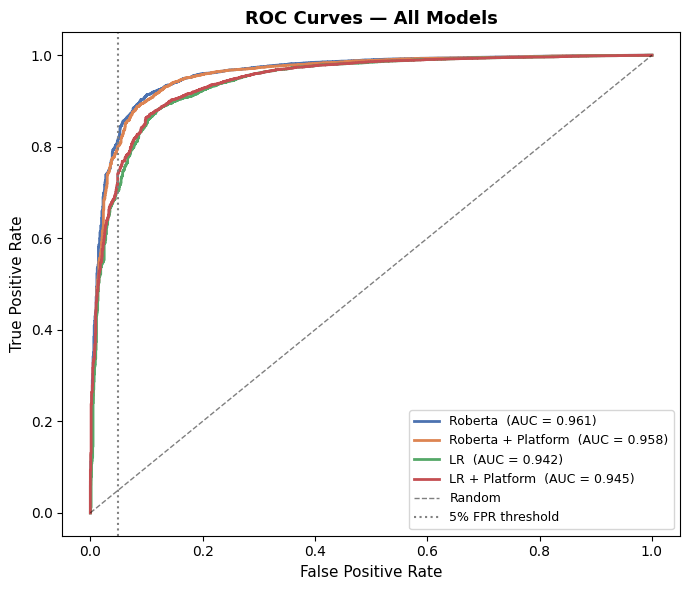

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for (name, r), color in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(r["test_labels"], r["test_probs"])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC = {r['auc_roc']:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
ax.axvline(x=0.05, color="gray", linestyle=":", lw=1.5, label="5% FPR threshold")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(f"{path}/outputs/plots/roc_curves.png", bbox_inches="tight", dpi=150)
plt.show()

### Confusion Matrices

Rows are true labels, columns are predicted labels.

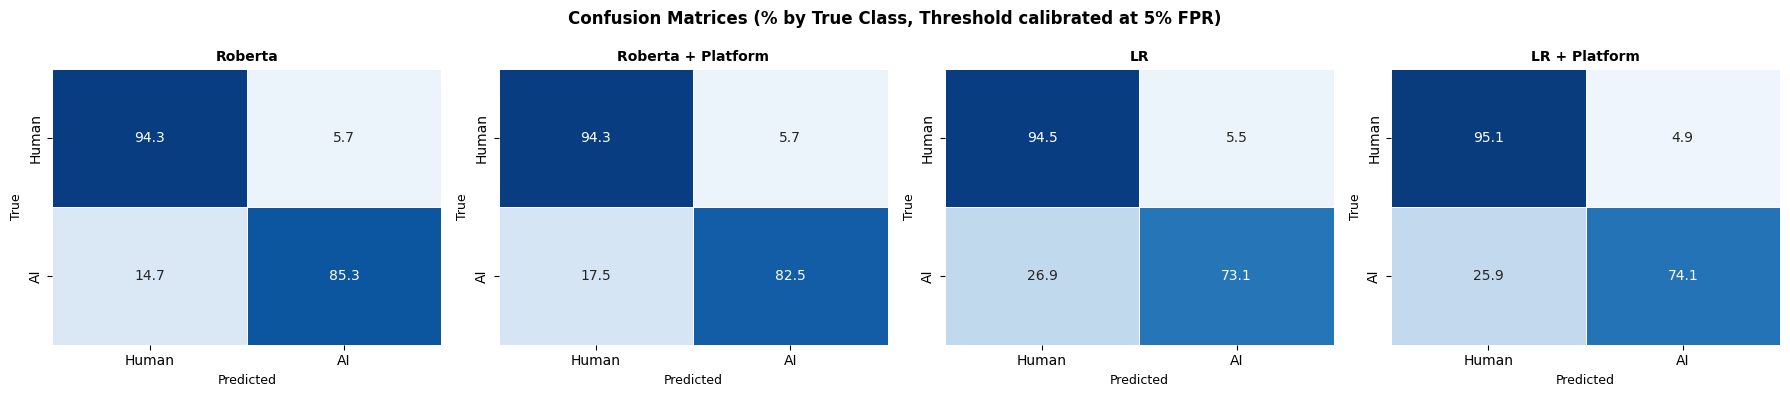

In [ ]:
class_names = ["Human", "AI"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["test_labels"], r["test_preds"], normalize="true") * 100
    sns.heatmap(
        cm, annot=True, fmt=".1f", cmap="Blues", ax=ax,
        xticklabels=class_names, yticklabels=class_names,
        cbar=False, linewidths=0.5, vmin=0, vmax=100,
    )
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True", fontsize=9)

fig.suptitle("Confusion Matrices (% by True Class, Threshold calibrated at 5% FPR)", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{path}/outputs/plots/confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()

## Platform Analysis

I evaluate each model separately on each social media platform.
This reveals whether detection performance is consistent across platforms or whether some platforms are harder.

/tmp/ipykernel_22005/2438255787.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
/tmp/ipykernel_22005/2438255787.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)


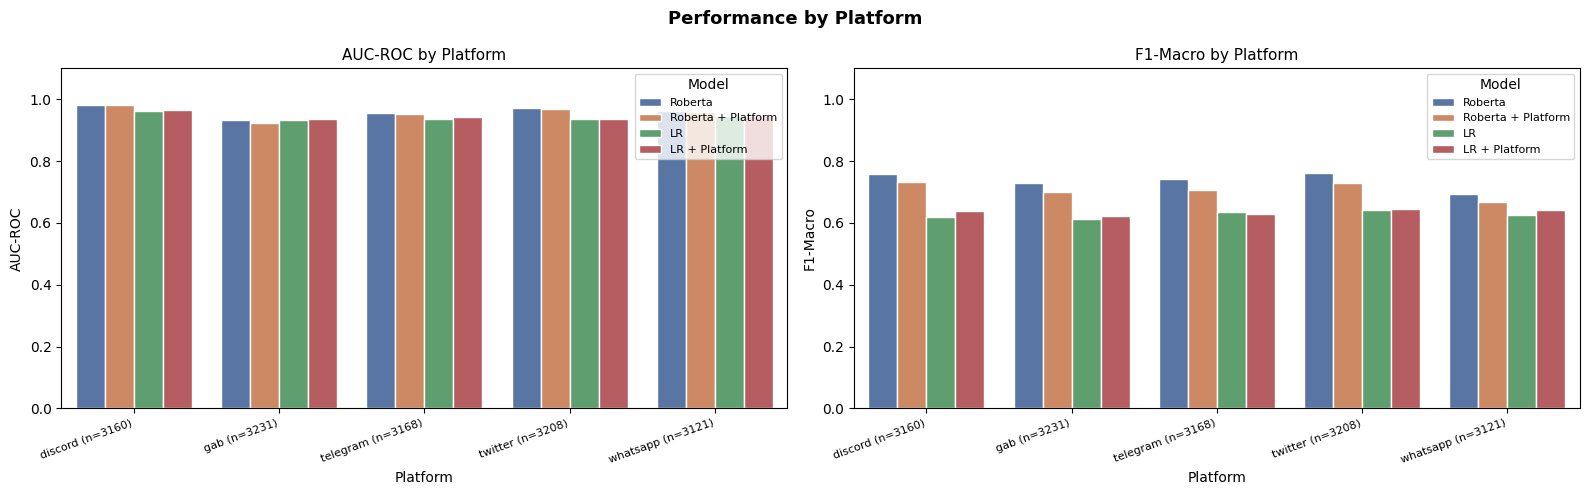

In [ ]:
platforms = sorted(test_df["source"].unique())
rows = []
for platform in platforms:
    mask = test_df["source"].values == platform
    n = int(mask.sum())
    for name, r in results.items():
        m = subset_metrics(r["test_probs"][mask], r["test_labels"][mask], r["threshold"])
        rows.append({"Platform": f"{platform} (n={n})", "Model": name, **m})

df_platform = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (label, col) in zip(axes, [("AUC-ROC", "auc_roc"), ("F1-Macro", "f1_macro")]):
    sns.barplot(
        data=df_platform, x="Platform", y=col, hue="Model",
        palette=COLORS, ax=ax, edgecolor="white",
    )
    ax.set_title(f"{label} by Platform", fontsize=11)
    ax.set_ylabel(label)
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
    ax.legend(fontsize=8, title="Model")

fig.suptitle("Performance by Platform", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{path}/outputs/plots/platform_analysis.png", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
df_platform["Platform_short"] = df_platform["Platform"].str.split(" ").str[0]
pivot = df_platform.pivot_table(index="Platform_short", columns="Model", values="auc_roc").round(3)
pivot.columns.name = None
pivot.index.name = "Platform"
print("AUC-ROC by Platform:")
pivot

AUC-ROC by Platform:


,LR,LR + Platform,Roberta,Roberta + Platform
Platform,,,,
discord,0.961,0.964,0.983,0.983
gab,0.934,0.936,0.932,0.924
telegram,0.936,0.943,0.957,0.954
twitter,0.936,0.936,0.971,0.969
whatsapp,0.945,0.946,0.961,0.960


## Post Length Analysis

Posts are binned by word count:
- **Short** — ≤ 10 words
- **Medium** — 11–23 words
- **Long** — > 23 words

Shorter posts typically contain less distinguishing signal, making AI detection harder.
I wanted to see if conditioned model performs better in shorter posts.

In [ ]:
label_order

['short\n(n=4169)', 'medium\n(n=3898)', 'long\n(n=7821)']

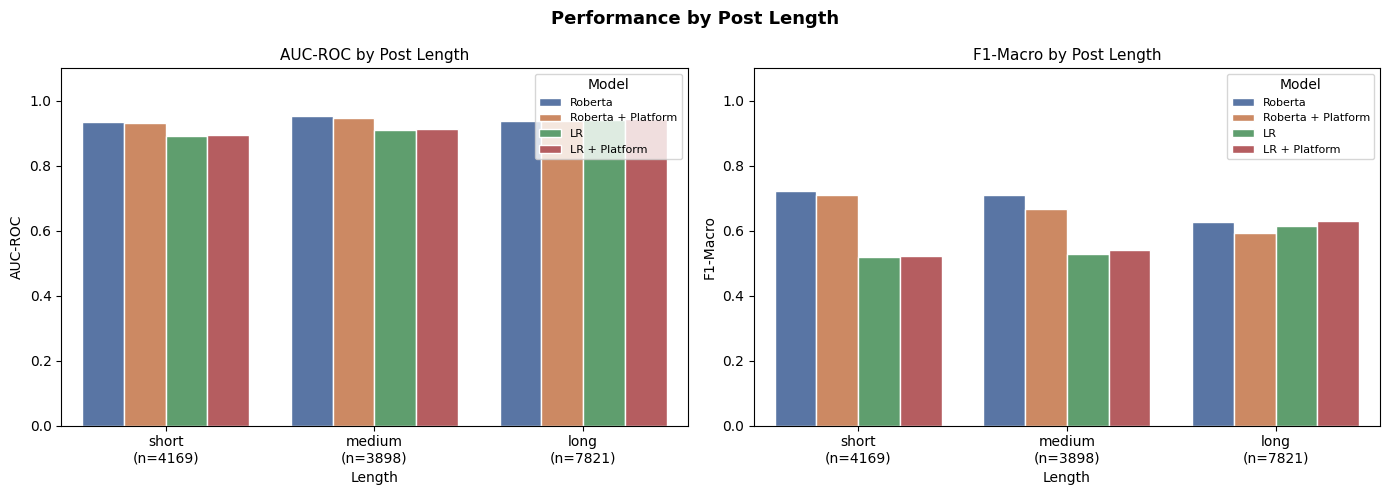

In [ ]:
length_order = ["short", "medium", "long"]
rows = []
for bin_name in length_order:
    mask = test_df["length_bin"].values == bin_name
    n = int(mask.sum())
    for name, r in results.items():
        m = subset_metrics(r["test_probs"][mask], r["test_labels"][mask], r["threshold"])
        rows.append({"Length": f"{bin_name}\n(n={n})", "Length_order": bin_name, "Model": name, **m})

df_length = pd.DataFrame(rows)
label_order = [f"{b}\n(n={int((test_df['length_bin'] == b).sum())})" for b in length_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, col) in zip(axes, [("AUC-ROC", "auc_roc"), ("F1-Macro", "f1_macro")]):
    sns.barplot(
        data=df_length, x="Length", y=col, hue="Model",
        palette=COLORS, ax=ax, order=label_order, edgecolor="white",
    )
    ax.set_title(f"{label} by Post Length", fontsize=11)
    ax.set_ylabel(label)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8, title="Model")

fig.suptitle("Performance by Post Length", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{path}/outputs/plots/length_analysis.png", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
# Summary table: AUC-ROC per length bin × model
pivot_len = df_length.pivot_table(
    index="Length_order", columns="Model", values="auc_roc"
).reindex(length_order).round(3)
pivot_len.columns.name = None
pivot_len.index.name = "Length Bin"
print("AUC-ROC by Post Length:")
pivot_len

AUC-ROC by Post Length:


,LR,LR + Platform,Roberta,Roberta + Platform
Length Bin,,,,
short,0.891,0.894,0.933,0.931
medium,0.911,0.913,0.954,0.947
long,0.941,0.943,0.937,0.939


In summary:
- Both conditioned and unconditioned roberta models perform better than the simple LR baseline
- The performance of conditioned roberta suprisingly is not better than the non-conditioned roberta. Although their performance seems quite identical.
- However, the performance of LR+Platform was a bit higher than the LR model
- Across differenet platforms, the results were consistant: Roberta>Roberta+platform and LR< LR+platform
- Analysis on post length show the same results proving that conditioning the models by prepending the platform token to the posts, does not improve the performance of the model in posts of certain length